In [1]:
# %pip install roboflow supervision opencv-python python-dotenv

- https://universe.roboflow.com/pokere-vision/poker_vision_3.0-bev73/model/1

In [2]:
from dotenv import load_dotenv
from roboflow import Roboflow
import supervision as sv
import cv2
import os

In [3]:
load_dotenv()
roboflow_api_key = os.getenv("roboflow_api_key")

In [4]:
rf = Roboflow(api_key=roboflow_api_key)
project = rf.workspace().project("poker_vision_3.0-bev73")
model = project.version(1).model

loading Roboflow workspace...
loading Roboflow project...


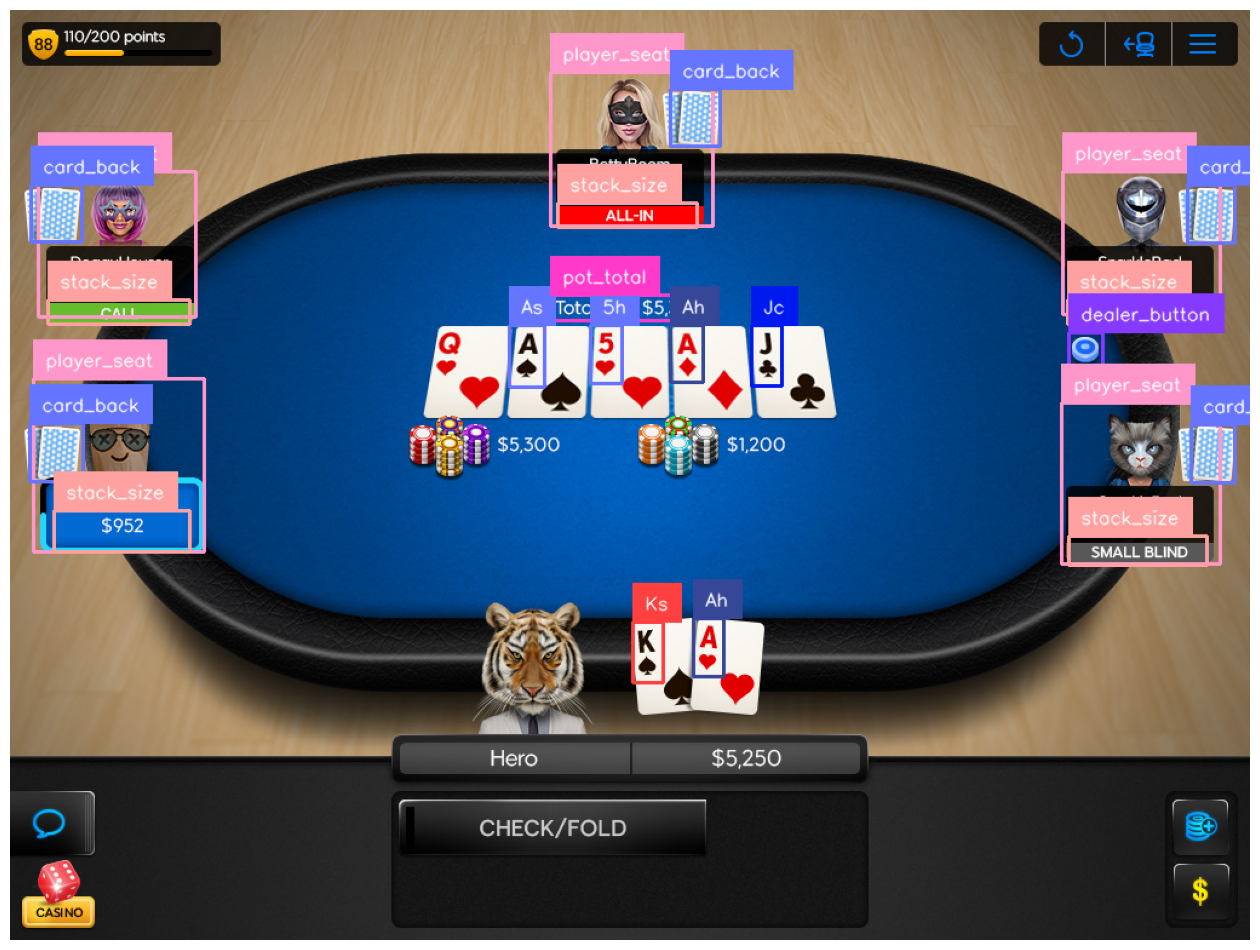

In [6]:
img_path = '../_data/resource/pokerboard_888poker_v1.jpg'
result = model.predict(img_path, confidence=40, overlap=30).json()
labels = [item["class"] for item in result["predictions"]]

detections = sv.Detections.from_inference(result)

label_annotator = sv.LabelAnnotator()
bounding_box_annotator = sv.BoxAnnotator()

image = cv2.imread(img_path)

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels)

sv.plot_image(image=annotated_image, size=(16, 16))

In [8]:
# img_path = '../_data/resource/pokerboard_888poker_v2.jpg'
# # img_path = '../_data/resource/pokerboard_play.jpg'
# # img_path = '../_data/resource/poker_5_card_v1.png'
# # img_path = '../_data/resource/poker_5_card_v2.png'
# result = model.predict(img_path, confidence=40, overlap=30).json()
# labels = [item["class"] for item in result["predictions"]]

# detections = sv.Detections.from_inference(result)

# label_annotator = sv.LabelAnnotator()
# bounding_box_annotator = sv.BoxAnnotator()

# image = cv2.imread(img_path)

# annotated_image = bounding_box_annotator.annotate(
#     scene=image, detections=detections)
# annotated_image = label_annotator.annotate(
#     scene=annotated_image, detections=detections, labels=labels)

# sv.plot_image(image=annotated_image, size=(16, 16))